<a href="https://colab.research.google.com/github/Rajukc45/Capstone-project/blob/main/week%205%20new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC

In [3]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

Saving creditcard.csv to creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    16383 non-null  int64  
 1   V1      16383 non-null  float64
 2   V2      16383 non-null  float64
 3   V3      16383 non-null  float64
 4   V4      16383 non-null  float64
 5   V5      16383 non-null  float64
 6   V6      16383 non-null  float64
 7   V7      16383 non-null  float64
 8   V8      16383 non-null  float64
 9   V9      16383 non-null  float64
 10  V10     16383 non-null  float64
 11  V11     16383 non-null  float64
 12  V12     16383 non-null  float64
 13  V13     16383 non-null  float64
 14  V14     16383 non-null  float64
 15  V15     16383 non-null  float64
 16  V16     16383 non-null  float64
 17  V17     16383 non-null  float64
 18  V18     16383 non-null  float64
 19  V19     16383 non-null  float64
 20  V20     16383 non-null  float64
 21  V21     16383 non-null  float64
 22

In [5]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_7023/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [8]:
# Assume 'Class' is label (0 = normal, 1 = attack)
X = df.drop('Class', axis=1)
y = df['Class']

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [11]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (11468, 30)
Validation shape: (2457, 30)
Test shape: (2458, 30)


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]

    print(classification_report(y_val, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

    auc = roc_auc_score(y_val, y_prob)
    print("AUC-ROC:", auc)

    results[name] = auc


Training Logistic Regression...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2446
           1       1.00      0.45      0.62        11

    accuracy                           1.00      2457
   macro avg       1.00      0.73      0.81      2457
weighted avg       1.00      1.00      1.00      2457

Confusion Matrix:
 [[2446    0]
 [   6    5]]
AUC-ROC: 0.939939047052702

Training Random Forest...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2446
           1       1.00      0.64      0.78        11

    accuracy                           1.00      2457
   macro avg       1.00      0.82      0.89      2457
weighted avg       1.00      1.00      1.00      2457

Confusion Matrix:
 [[2446    0]
 [   4    7]]
AUC-ROC: 0.813870512153423

Training SVM...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2446
           1  

In [13]:
iso = IsolationForest(contamination=0.01, random_state=42)
iso.fit(X_train)

y_pred_iso = iso.predict(X_val)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)  # Convert to binary

print("\nIsolation Forest Results")
print(classification_report(y_val, y_pred_iso))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_iso))


Isolation Forest Results
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2446
           1       0.25      0.55      0.34        11

    accuracy                           0.99      2457
   macro avg       0.62      0.77      0.67      2457
weighted avg       0.99      0.99      0.99      2457

Confusion Matrix:
 [[2428   18]
 [   5    6]]


In [14]:
print("\nModel AUC Scores:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Model AUC Scores:
Logistic Regression: 0.9399
Random Forest: 0.8139
SVM: 0.9653


In [15]:
best_model = RandomForestClassifier(n_estimators=100)
best_model.fit(X_train, y_train)

# Evaluate on Test Set
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:,1]

print("\nFinal Test Performance")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_test_prob))


Final Test Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.79      1.00      0.88        11

    accuracy                           1.00      2458
   macro avg       0.89      1.00      0.94      2458
weighted avg       1.00      1.00      1.00      2458

Confusion Matrix:
 [[2444    3]
 [   0   11]]
AUC-ROC: 0.9998885462718728


In [19]:

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense
#
# model = Sequential()
# model.add(LSTM(50, input_shape=(X_train.shape[1], 1)))
# model.add(Dense(1, activation='sigmoid'))
#
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
#
# model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y

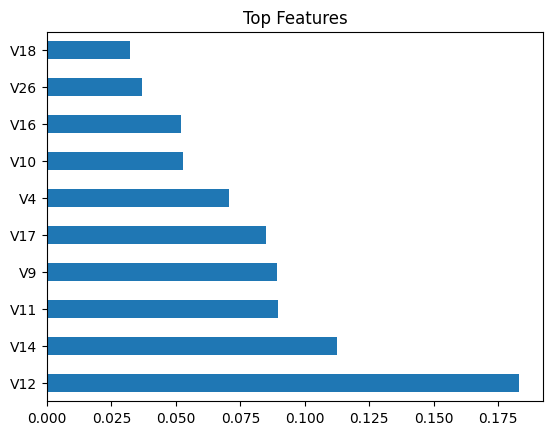

In [16]:
# Assuming sequential data (optional placeholder)
# latency = time_detected - time_attack_started

# ==============================
# 14. Feature Importance (Random Forest)
# ==============================

importances = best_model.feature_importances_
features = X.columns

feat_importance = pd.Series(importances, index=features)
feat_importance.nlargest(10).plot(kind='barh')
plt.title("Top Features")
plt.show()


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [23]:
log_model = LogisticRegression(max_iter=1000)

In [24]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_val_pred = log_model.predict(X_val)
y_val_prob = log_model.predict_proba(X_val)[:, 1]

In [26]:
print("=== Logistic Regression (Validation) ===")
print(classification_report(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

auc = roc_auc_score(y_val, y_val_prob)
print("AUC-ROC:", auc)

=== Logistic Regression (Validation) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2446
           1       1.00      0.45      0.62        11

    accuracy                           1.00      2457
   macro avg       1.00      0.73      0.81      2457
weighted avg       1.00      1.00      1.00      2457

Confusion Matrix:
 [[2446    0]
 [   6    5]]
AUC-ROC: 0.939939047052702


In [27]:
y_test_pred = log_model.predict(X_test)
y_test_prob = log_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Test) ===")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_test_prob))

=== Logistic Regression (Test) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.73      0.73      0.73        11

    accuracy                           1.00      2458
   macro avg       0.86      0.86      0.86      2458
weighted avg       1.00      1.00      1.00      2458

Confusion Matrix:
 [[2444    3]
 [   3    8]]
AUC-ROC: 0.9980681353791284


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [29]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


In [30]:
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
y_val_pred_log = log_model.predict(X_val)
y_val_prob_log = log_model.predict_proba(X_val)[:, 1]


In [33]:
y_val_pred_rf = rf_model.predict(X_val)
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

In [35]:
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("AUC-ROC:", roc_auc_score(y_true, y_prob))

In [36]:
evaluate_model("Logistic Regression", y_val, y_val_pred_log, y_val_prob_log)
evaluate_model("Random Forest", y_val, y_val_pred_rf, y_val_prob_rf)


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2446
           1       0.44      0.64      0.52        11

    accuracy                           0.99      2457
   macro avg       0.72      0.82      0.76      2457
weighted avg       1.00      0.99      1.00      2457

Confusion Matrix:
 [[2437    9]
 [   4    7]]
AUC-ROC: 0.9198320077306178

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2446
           1       1.00      0.64      0.78        11

    accuracy                           1.00      2457
   macro avg       1.00      0.82      0.89      2457
weighted avg       1.00      1.00      1.00      2457

Confusion Matrix:
 [[2446    0]
 [   4    7]]
AUC-ROC: 0.8134245149780718


In [37]:
# ==============================
# Test Predictions
# ==============================
y_test_pred_log = log_model.predict(X_test)
y_test_prob_log = log_model.predict_proba(X_test)[:, 1]

y_test_pred_rf = rf_model.predict(X_test)
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ==============================
# Final Evaluation
# ==============================
evaluate_model("Logistic Regression (Test)", y_test, y_test_pred_log, y_test_prob_log)
evaluate_model("Random Forest (Test)", y_test, y_test_pred_rf, y_test_prob_rf)


===== Logistic Regression (Test) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.58      1.00      0.73        11

    accuracy                           1.00      2458
   macro avg       0.79      1.00      0.87      2458
weighted avg       1.00      1.00      1.00      2458

Confusion Matrix:
 [[2439    8]
 [   0   11]]
AUC-ROC: 0.9991083701749824

===== Random Forest (Test) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.85      1.00      0.92        11

    accuracy                           1.00      2458
   macro avg       0.92      1.00      0.96      2458
weighted avg       1.00      1.00      1.00      2458

Confusion Matrix:
 [[2445    2]
 [   0   11]]
AUC-ROC: 0.9998513950291636


In [38]:
import pandas as pd

results = []

def collect_results(name, y_true, y_pred, y_prob):
    from sklearn.metrics import precision_score, recall_score, f1_score
    results.append({
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    })

collect_results("Logistic Regression", y_test, y_test_pred_log, y_test_prob_log)
collect_results("Random Forest", y_test, y_test_pred_rf, y_test_prob_rf)

df_results = pd.DataFrame(results)
print(df_results)

                 Model  Precision  Recall  F1-score       AUC
0  Logistic Regression   0.578947     1.0  0.733333  0.999108
1        Random Forest   0.846154     1.0  0.916667  0.999851
